# Plotting ligation statistics

This notebook demonstrates how aggregated outputs from the in-silico Hi-C pipeline are used to generate representative figures.

# Purpose

- Load aggregated `.npz` data from the `data/processed/` directory  
- Compute and visualize:
  - ligation probability vs genomic distance  
  - ligation probability vs Euclidean distance  
  - related distance-dependent observables  
- Compare simulation results with experimental Hi-C data (when available)

# Notes

- This notebook is **representative** and is not intended to reproduce every individual figure panel in the manuscript.
- Paths are set relative to the repository root for portability.
- The file `experimental-hic.npz` is included to enable comparison with experimental data in selected figures.

## Input data

- Aggregated simulation data:
  - `../../data/processed/*.npz`
- Experimental data:
  - `../../data/processed/experimental/experimental-hic.npz`
  
**Note:** The `.npz` datasets required for this notebook are not included in this repository and are available on Zenodo: https://doi.org/10.5281/zenodo.19682913

In [ ]:
import mdtraj as md
import mbuild as mb
import numpy  as np
import random
import os.path
import sys
import scipy as sp
from scipy.spatial import distance
import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.sparse as sparse
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
#Input npz files with aggregated data for different digestion efficiencies (number of cuts along the polymer)

data_dir = "../../data/processed/digestion_efficiency/"
g_diff_500 = np.load(data_dir+'/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_5000_rc_1.5.npz', allow_pickle=True)
g_diff_1000 = np.load(data_dir+'/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_4500_rc_1.5.npz', allow_pickle=True)
g_diff_3000 = np.load(data_dir+'/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_2500_rc_1.5.npz', allow_pickle=True)
g_diff_5000 = np.load(data_dir+'/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_500_rc_1.5.npz', allow_pickle=True)

In [ ]:
print(g_diff_500.files, g_diff_1000.files, g_diff_3000.files, g_diff_5000.files) 

['ligation_prob_global', 'ligation_map_global', 'ligation_events', 'self_ligation_events', 'nf', 'p_ligation1', 'p_ligation2', 'ligation_distances', 'init_contact_map_final', 'init_contact_map_final_2', 'rthresh', 'initial_distance_final', 'Pcycle_L_final', 'Ncycle_L_final', 'Nlong_L_final', 'cycle_bins', 'ligation_map_global_new', 'ligation_prob_global_new', 'p_ligation_new', 'tot_nlig_new', 'cum_history_mat'] ['ligation_prob_global', 'ligation_map_global', 'ligation_events', 'self_ligation_events', 'nf', 'p_ligation1', 'p_ligation2', 'ligation_distances', 'init_contact_map_final', 'init_contact_map_final_2', 'rthresh', 'initial_distance_final', 'Pcycle_L_final', 'Ncycle_L_final', 'Nlong_L_final', 'cycle_bins', 'ligation_map_global_new', 'ligation_prob_global_new', 'p_ligation_new', 'tot_nlig_new', 'cum_history_mat'] ['ligation_prob_global', 'ligation_map_global', 'ligation_events', 'self_ligation_events', 'nf', 'p_ligation1', 'p_ligation2', 'ligation_distances', 'init_contact_map_fin

In [5]:
lpg_d_500=g_diff_500['ligation_prob_global']
lmg_d_500=g_diff_500['ligation_map_global']
lev_d_500=g_diff_500['ligation_events']
sle_d_500=g_diff_500['self_ligation_events']
nf_d_500=g_diff_500['nf']
pl1_d_500=g_diff_500['p_ligation1']
pl2_d_500=g_diff_500['p_ligation2']
ld_d_500=g_diff_500['ligation_distances']

Nlong_L_d_500=g_diff_500['Nlong_L_final']
Pcycle_L_d_500=g_diff_500['Pcycle_L_final']
Ncycle_L_d_500=g_diff_500['Ncycle_L_final']
cycle_bins_d_500=g_diff_500['cycle_bins']
icm_d_500=g_diff_500['init_contact_map_final']
icm2_d_500=g_diff_500['init_contact_map_final_2']
rthresh_d_500=g_diff_500['rthresh']
idm_d_500=g_diff_500['initial_distance_final']
nf_d_500=g_diff_500['nf']

lmgn_d_500=g_diff_500['ligation_map_global_new']
lpgn_d_500=g_diff_500['ligation_prob_global_new']
pln_d_500=g_diff_500['p_ligation_new']
tnln_d_500=g_diff_500['tot_nlig_new']
hist_d_500=g_diff_500['cum_history_mat']

lpg_d_1000=g_diff_1000['ligation_prob_global']
lmg_d_1000=g_diff_1000['ligation_map_global']
lev_d_1000=g_diff_1000['ligation_events']
sle_d_1000=g_diff_1000['self_ligation_events']
nf_d_1000=g_diff_1000['nf']
pl1_d_1000=g_diff_1000['p_ligation1']
pl2_d_1000=g_diff_1000['p_ligation2']
ld_d_1000=g_diff_1000['ligation_distances']

Nlong_L_d_1000=g_diff_1000['Nlong_L_final']
Pcycle_L_d_1000=g_diff_1000['Pcycle_L_final']
Ncycle_L_d_1000=g_diff_1000['Ncycle_L_final']
cycle_bins_d_1000=g_diff_1000['cycle_bins']
icm_d_1000=g_diff_1000['init_contact_map_final']
icm2_d_1000=g_diff_1000['init_contact_map_final_2']
rthresh_d_1000=g_diff_1000['rthresh']
idm_d_1000=g_diff_1000['initial_distance_final']
nf_d_1000=g_diff_1000['nf']

lmgn_d_1000=g_diff_1000['ligation_map_global_new']
lpgn_d_1000=g_diff_1000['ligation_prob_global_new']
pln_d_1000=g_diff_1000['p_ligation_new']
tnln_d_1000=g_diff_1000['tot_nlig_new']
hist_d_1000=g_diff_1000['cum_history_mat']

lpg_d_3000=g_diff_3000['ligation_prob_global']
lmg_d_3000=g_diff_3000['ligation_map_global']
lev_d_3000=g_diff_3000['ligation_events']
sle_d_3000=g_diff_3000['self_ligation_events']
nf_d_3000=g_diff_3000['nf']
pl1_d_3000=g_diff_3000['p_ligation1']
pl2_d_3000=g_diff_3000['p_ligation2']
ld_d_3000=g_diff_3000['ligation_distances']

Nlong_L_d_3000=g_diff_3000['Nlong_L_final']
Pcycle_L_d_3000=g_diff_3000['Pcycle_L_final']
Ncycle_L_d_3000=g_diff_3000['Ncycle_L_final']
cycle_bins_d_3000=g_diff_3000['cycle_bins']
icm_d_3000=g_diff_3000['init_contact_map_final']
icm2_d_3000=g_diff_3000['init_contact_map_final_2']
rthresh_d_3000=g_diff_3000['rthresh']
idm_d_3000=g_diff_3000['initial_distance_final']
nf_d_3000=g_diff_3000['nf']

lmgn_d_3000=g_diff_3000['ligation_map_global_new']
lpgn_d_3000=g_diff_3000['ligation_prob_global_new']
pln_d_3000=g_diff_3000['p_ligation_new']
tnln_d_3000=g_diff_3000['tot_nlig_new']
hist_d_3000=g_diff_3000['cum_history_mat']

lpg_d_5000=g_diff_5000['ligation_prob_global']
lmg_d_5000=g_diff_5000['ligation_map_global']
lev_d_5000=g_diff_5000['ligation_events']
sle_d_5000=g_diff_5000['self_ligation_events']
nf_d_5000=g_diff_5000['nf']
pl1_d_5000=g_diff_5000['p_ligation1']
pl2_d_5000=g_diff_5000['p_ligation2']
ld_d_5000=g_diff_5000['ligation_distances']

Nlong_L_d_5000=g_diff_5000['Nlong_L_final']
Pcycle_L_d_5000=g_diff_5000['Pcycle_L_final']
Ncycle_L_d_5000=g_diff_5000['Ncycle_L_final']
cycle_bins_d_5000=g_diff_5000['cycle_bins']
icm_d_5000=g_diff_5000['init_contact_map_final']
icm2_d_5000=g_diff_5000['init_contact_map_final_2']
rthresh_d_5000=g_diff_5000['rthresh']
idm_d_5000=g_diff_5000['initial_distance_final']
nf_d_5000=g_diff_5000['nf']

lmgn_d_5000=g_diff_5000['ligation_map_global_new']
lpgn_d_5000=g_diff_5000['ligation_prob_global_new']
pln_d_5000=g_diff_5000['p_ligation_new']
tnln_d_5000=g_diff_5000['tot_nlig_new']
hist_d_5000=g_diff_5000['cum_history_mat']

In [ ]:
print(lev_d_3000) 

[array([10630520.,  9577316.,  6589737.,  4172915.]) 47626233670]


In [ ]:
print(lpg_d_3000.shape,lmg_d_3000.shape,lev_d_3000.shape,nf_d_3000.shape,pl1_d_3000.shape,pl2_d_3000.shape,ld_d_3000.shape)

(4, 5499) (4, 5500, 5500) (2,) () (4, 49) (4, 49) (50,)


In [32]:
lig_probs = np.array([1.0,0.1,0.01,0.001])
No_cuts = np.array([500, 1000, 3000, 5000])
p_legend = [r'$p = $'+str(1.0)+r' $p_o$',r'$p = $'+str(0.1)+r' $p_o$',r'$p = $'+str(0.01)+r' $p_o$',r'$p = $'+str(0.001)+r' $p_o$']
cuts_legend = ['No. cuts = '+str(500),'No. cuts = '+str(1000),'No. cuts = '+str(3000) ,'No. cuts = '+str(5000)]
Ncuts = len(No_cuts)
Nprobs = len(lig_probs)

In [33]:
print(len(lpg_d_500[2]))
gen_dist = np.linspace(0,5499,5499, dtype=int)
print(gen_dist)

5499
[   0    1    2 ... 5496 5497 5499]


In [34]:
xticks = np.linspace(1, 5500, 5499)
scale_factor = 200
scaled_xticks = scale_factor*xticks

In [ ]:
#Import experimental data from npz file at a resultion of 1KB
g_exp=np.load("../../data/processed/experimental/experimental-hic.npz", allow_pickle=True)
exp_ligprob = g_exp['exp_ligprob']
exp_map     = g_exp['ex_map']

In [37]:
#Calculation ligation probability vs genomic distance for experimental data
dmax = exp_map.shape[0] - 1
init = 1
contact_map_average = exp_map
contact_prob_average = np.zeros(dmax)
for i in range(dmax):
    contact_prob_average[i] =  np.mean(np.diagonal(contact_map_average, offset=(i+init)))    
normalize = contact_prob_average/np.sum(contact_prob_average)

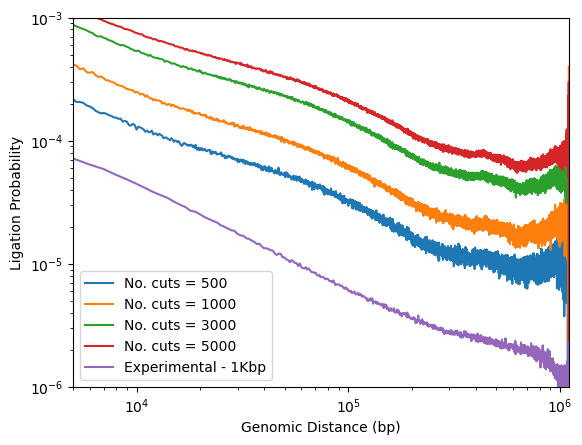

In [ ]:
#Ligation Frequencies as a function of genomic distance for p/p_o = 1 for different digestion efficiencies, with a comparison with experiment

plt.plot(scaled_xticks, lpg_d_500[0])
plt.plot(scaled_xticks, lpg_d_1000[0])
plt.plot(scaled_xticks, lpg_d_3000[0])
plt.plot(scaled_xticks, lpg_d_5000[0])

cuts_exp_legend = ['No. cuts = '+str(500),'No. cuts = '+str(1000),'No. cuts = '+str(3000) ,'No. cuts = '+str(5000), 'Experimental - 1Kbp']
                   
xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
plt.plot(scaled_xticks_exp, normalize/200)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(cuts_exp_legend)
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Probability')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-6,1e-3])
plt.xlim([5000,5500*200])
plt.show()

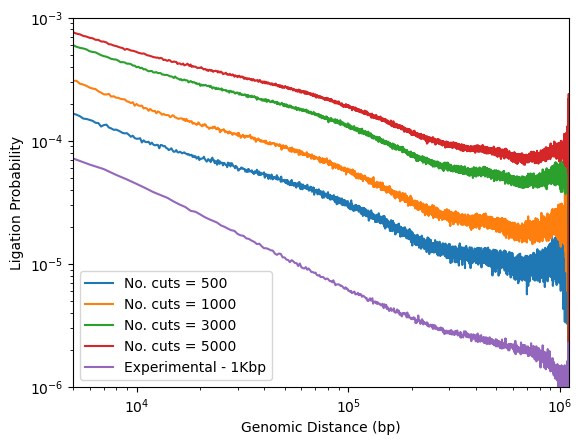

In [ ]:
#Ligation Frequencies as a function of genomic distance for p/p_o = 0.1 for different digestion efficiencies, with a comparison with experiment

plt.plot(scaled_xticks, lpg_d_500[1])
plt.plot(scaled_xticks, lpg_d_1000[1])
plt.plot(scaled_xticks, lpg_d_3000[1])
plt.plot(scaled_xticks, lpg_d_5000[1])

cuts_exp_legend = ['No. cuts = '+str(500),'No. cuts = '+str(1000),'No. cuts = '+str(3000) ,'No. cuts = '+str(5000), 'Experimental - 1Kbp']
                   
xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
plt.plot(scaled_xticks_exp, normalize/200)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(cuts_exp_legend)
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Probability')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-6,1e-3])
plt.xlim([5000,5500*200])
plt.show()

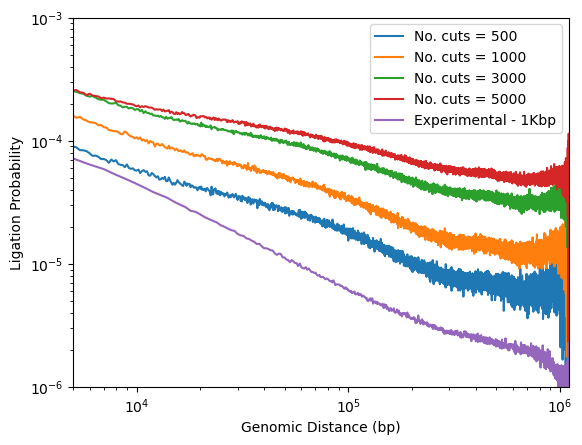

In [ ]:
#Ligation Frequencies as a function of genomic distance for p/p_o = 0.01 for different digestion efficiencies, with a comparison with experiment

plt.plot(scaled_xticks, lpg_d_500[2])
plt.plot(scaled_xticks, lpg_d_1000[2])
plt.plot(scaled_xticks, lpg_d_3000[2])
plt.plot(scaled_xticks, lpg_d_5000[2])

cuts_exp_legend = ['No. cuts = '+str(500),'No. cuts = '+str(1000),'No. cuts = '+str(3000) ,'No. cuts = '+str(5000), 'Experimental - 1Kbp']
                   
xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
plt.plot(scaled_xticks_exp, normalize/200)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(cuts_exp_legend)
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Probability')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-6,1e-3])
plt.xlim([5000,5500*200])
plt.show()

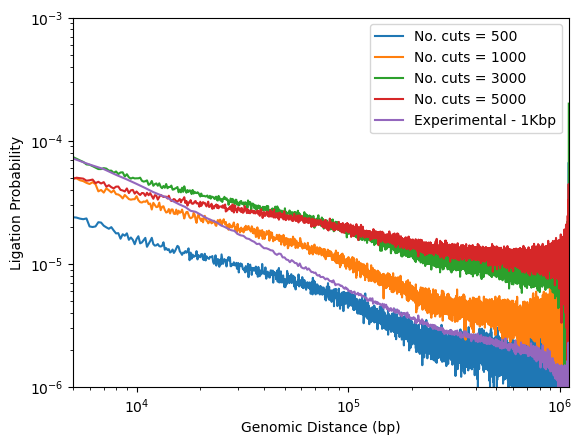

In [ ]:
#Ligation Frequencies as a function of genomic distance for p/p_o = 0.001 for different digestion efficiencies, with a comparison with experiment

plt.plot(scaled_xticks, lpg_d_500[3])
plt.plot(scaled_xticks, lpg_d_1000[3])
plt.plot(scaled_xticks, lpg_d_3000[3])
plt.plot(scaled_xticks, lpg_d_5000[3])

cuts_exp_legend = ['No. cuts = '+str(500),'No. cuts = '+str(1000),'No. cuts = '+str(3000) ,'No. cuts = '+str(5000), 'Experimental - 1Kbp']
                   
xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
plt.plot(scaled_xticks_exp, normalize/200)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(cuts_exp_legend)
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Probability')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-6,1e-3])
plt.xlim([5000,5500*200])
plt.show()

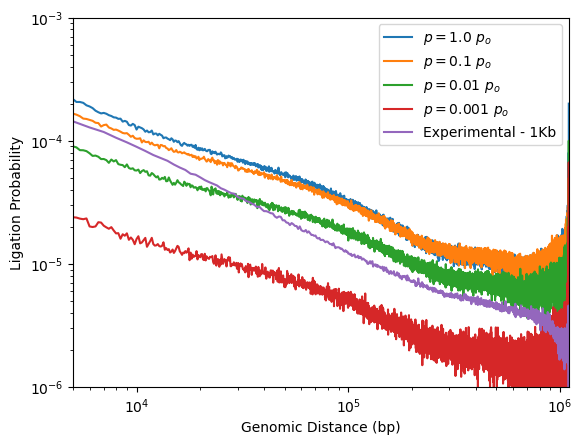

In [ ]:
#Ligation Frequencies as a function of genomic distance for 500 digestion cuts and different ligation efficiencies, with a comparison with experiment

plt.plot(scaled_xticks, lpg_d_500[0])
plt.plot(scaled_xticks, lpg_d_500[1])
plt.plot(scaled_xticks, lpg_d_500[2])
plt.plot(scaled_xticks, lpg_d_500[3])

po_legend = [r'$p = $'+str(1.0)+r' $p_o$',r'$p = $'+str(0.1)+r' $p_o$',r'$p = $'+str(0.01)+r' $p_o$',r'$p = $'+str(0.001)+r' $p_o$', 'Experimental - 1Kb']

xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
plt.plot(scaled_xticks_exp, normalize/100)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(po_legend)
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Probability')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-6,1e-3])
plt.xlim([5000,5500*200])
plt.show()

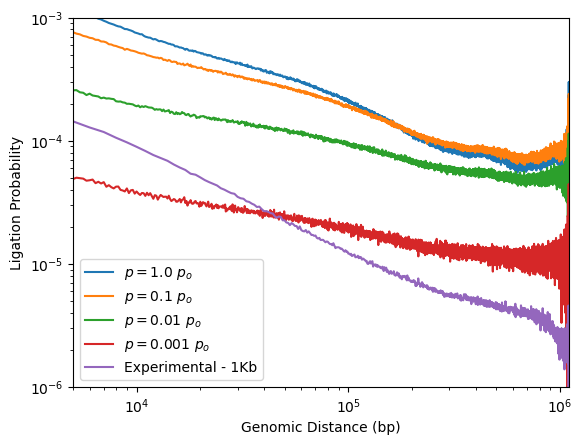

In [ ]:
#Ligation Frequencies as a function of genomic distance for 5000 digestion cuts and different ligation efficiencies, with a comparison with experiment

plt.plot(scaled_xticks, lpg_d_5000[0])
plt.plot(scaled_xticks, lpg_d_5000[1])
plt.plot(scaled_xticks, lpg_d_5000[2])
plt.plot(scaled_xticks, lpg_d_5000[3])

po_legend = [r'$p = $'+str(1.0)+r' $p_o$',r'$p = $'+str(0.1)+r' $p_o$',r'$p = $'+str(0.01)+r' $p_o$',r'$p = $'+str(0.001)+r' $p_o$', 'Experimental - 1Kb']

xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
plt.plot(scaled_xticks_exp, normalize/100)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(po_legend)
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Probability')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-6,1e-3])
plt.xlim([5000,5500*200])
plt.show()

In [198]:
print(scaled_xticks[2999])

600109.0942160785


In [ ]:
#Fits of power-law scaling exponents for ligation probabilities as a function of genomic distance

from scipy.optimize import curve_fit

def power_fit(x, a, alpha):
    return a*x**alpha

#print(len(scaled_xticks), len(cont_prob_5500))

lower_bound = 100 #49
upper_bound = 2999 #499

params_0500 = []
params_1000 = []
params_3000 = []
params_5000 = []

slope_p1e0 = []
slope_p1e1 = []
slope_p1e2 = []
slope_p1e3 = []

params_exp,  covariance_exp  = curve_fit(f = power_fit, xdata = scaled_xticks_exp[2:99], ydata = normalize[2:99], maxfev=10000)

for i in range(Nprobs):

    param_0500, covariance_0500 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_d_500[i][lower_bound:upper_bound], maxfev=10000)
    param_1000, covariance_1000 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_d_1000[i][lower_bound:upper_bound], maxfev=10000)
    param_3000, covariance_3000 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_d_3000[i][lower_bound:upper_bound], maxfev=10000)
    param_5000, covariance_5000 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_d_5000[i][lower_bound:upper_bound], maxfev=10000)

    params_0500.append(param_0500[1])
    params_1000.append(param_1000[1])
    params_3000.append(param_3000[1])
    params_5000.append(param_5000[1])
    
    #print(param_5000)
    
slope_p1e0 = np.abs([params_0500[0], params_1000[0], params_3000[0], params_5000[0]])
slope_p1e1 = np.abs([params_0500[1], params_1000[1], params_3000[1], params_5000[1]])
slope_p1e2 = np.abs([params_0500[2], params_1000[2], params_3000[2], params_5000[2]])
slope_p1e3 = np.abs([params_0500[3], params_1000[3], params_3000[3], params_5000[3]])
                
params_0500 = np.abs(params_0500)
params_1000 = np.abs(params_1000)
params_3000 = np.abs(params_3000)
params_5000 = np.abs(params_5000)  


    
x= scaled_xticks_exp[2:99]

print(params_exp)
#plt.plot(x, power_fit(x, params_exp[0], params_exp[1]))

#x= scaled_xticks[14:499]
#plt.plot(x, power_fit(x, params_0500[0], params_0500[1]))
#plt.plot(x, power_fit(x, params_1000[0], params_1000[1]))
#plt.plot(x, power_fit(x, params_3000[0], params_3000[1]))
#plt.plot(x, power_fit(x, params_5000[0], params_5000[1]))



[ 8.46728259 -0.75351583]


In [147]:
scaled_xticks[24]

5000.873044743544

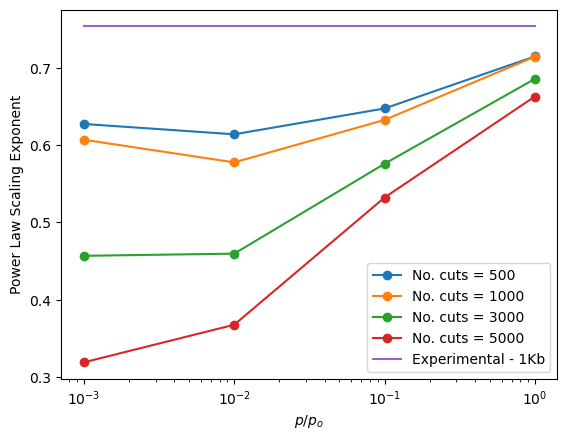

In [ ]:
#Power-law scaling exponent dependence of ligation probabilities as a function of ligation rate for different digestion efficiencies

p_legend = ['No. cuts = '+str(500),'No. cuts = '+str(1000),'No. cuts = '+str(3000),'No. cuts = '+str(5000), 'Experimental - 1Kb']

plt.plot(lig_probs, params_0500, marker = 'o')
plt.plot(lig_probs, params_1000, marker = 'o')
plt.plot(lig_probs, params_3000, marker = 'o')
plt.plot(lig_probs, params_5000, marker = 'o')

x = [1e-3, 1]
y = [abs(params_exp[1]),abs(params_exp[1])]

plt.plot(x, y)

plt.ylabel('Power Law Scaling Exponent')

plt.xlabel(r'$p/p_{o} $')

#plt.yscale("log")
plt.xscale("log")

plt.legend(p_legend)#loc='upper right')

plt.show()



In [16]:
print(len(ld_d_500), len(lpg_d_500[2]))

50 5499


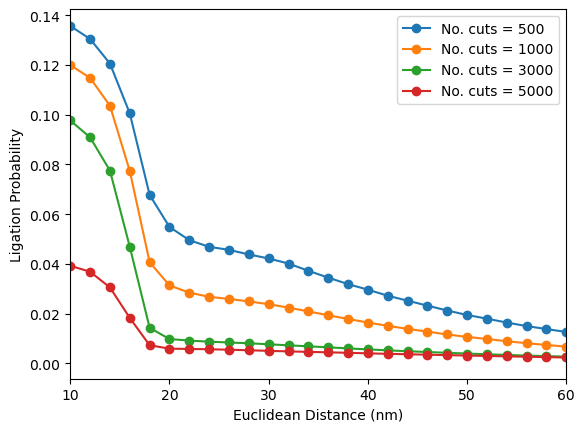

In [ ]:
#Ligation frequency as a function of Euclidean distance for different digestion efficiencies

plt.plot(10*ld_d_500[0:49],pl1_d_500[0], '-o')
plt.plot(10*ld_d_1000[0:49],pl1_d_1000[0], '-o')
plt.plot(10*ld_d_3000[0:49],pl1_d_3000[0], '-o')
plt.plot(10*ld_d_5000[0:49],pl1_d_5000[0], '-o')

#plt.plot(10*ld[0:49],pl1[5], '-o')
plt.legend(cuts_legend)
plt.xlim([10,60])
#plt.ylim([0,0.02])
#plt.yscale("log")
plt.xlabel('Euclidean Distance (nm)')
plt.ylabel('Ligation Probability')
plt.show()

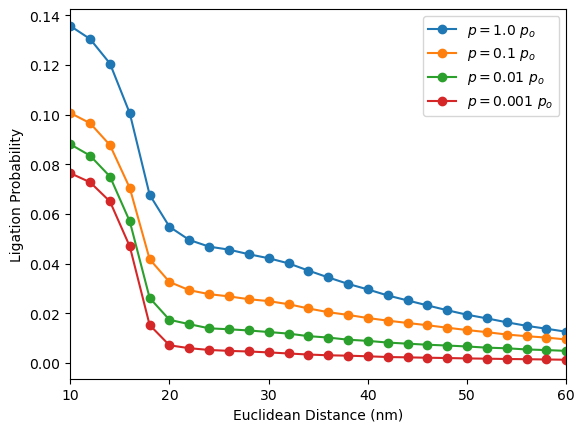

In [ ]:
#Ligation frequency as a function of Euclidean distance for different ligation efficiencies and fixed digestion efficiency

plt.plot(10*ld_d_500[0:49],pl1_d_500[0], '-o')
plt.plot(10*ld_d_500[0:49],pl1_d_500[1], '-o')
plt.plot(10*ld_d_500[0:49],pl1_d_500[2], '-o')
plt.plot(10*ld_d_500[0:49],pl1_d_500[3], '-o')

#plt.plot(10*ld[0:49],pl1[5], '-o')
plt.legend(p_legend)
plt.xlim([10,60])
#plt.ylim([0,0.02])
#plt.yscale("log")
plt.xlabel('Euclidean Distance (nm)')
plt.ylabel('Ligation Probability')
plt.show()